# Experiment 5: Decision Tree and Random Forest

# 1. Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc)

%matplotlib inline


# 2. Load and Inspect the Dataset

In [33]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = malignant, 1 = benign (sklearn's default encoding)

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [34]:
print("Dataset shape:", df.shape)


Dataset shape: (569, 31)


In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [36]:
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [37]:
df.isnull().sum()


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

# 3. Class Label Encoding

In [38]:
# sklearn's breast cancer dataset already encodes target as 0/1
# 0 -> malignant, 1 -> benign
target_names = data.target_names
print(target_names)

label_map = {0: 'Malignant', 1: 'Benign'}
df['diagnosis'] = df['target'].map(label_map)

df[['target', 'diagnosis']].head()


['malignant' 'benign']


,target,diagnosis
0,0,Malignant
1,0,Malignant
2,0,Malignant
3,0,Malignant
4,0,Malignant


In [39]:
print("Class mapping:")
print("0 -> Malignant")
print("1 -> Benign")

df['diagnosis'].value_counts()


Class mapping:
0 -> Malignant
1 -> Benign


diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

# 4. Exploratory Data Analysis

### Class Distribution

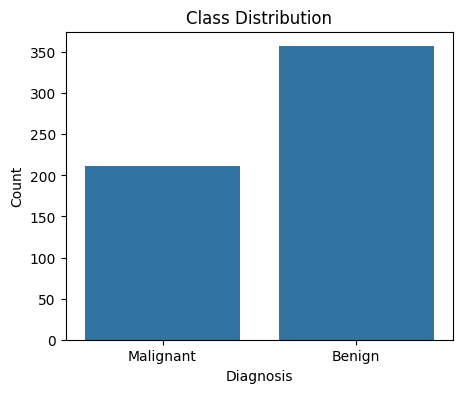

In [40]:
plt.figure(figsize=(5,4))
sns.countplot(x='diagnosis', data=df)
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


### Feature Correlation Analysis

In [41]:
corr = df[data.feature_names].corr()

corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

corr_pairs['Absolute Correlation'] = corr_pairs['Correlation'].abs()

top_corr = corr_pairs.sort_values(
    'Absolute Correlation',
    ascending=False
).head(10)

top_corr[['Feature 1', 'Feature 2', 'Correlation']]

,Feature 1,Feature 2,Correlation
1,mean radius,mean perimeter,0.997855
391,worst radius,worst perimeter,0.993708
2,mean radius,mean area,0.987357
57,mean perimeter,mean area,0.986507
392,worst radius,worst area,0.984015
407,worst perimeter,worst area,0.977578
246,radius error,perimeter error,0.972794
76,mean perimeter,worst perimeter,0.970387
19,mean radius,worst radius,0.969539
74,mean perimeter,worst radius,0.969476


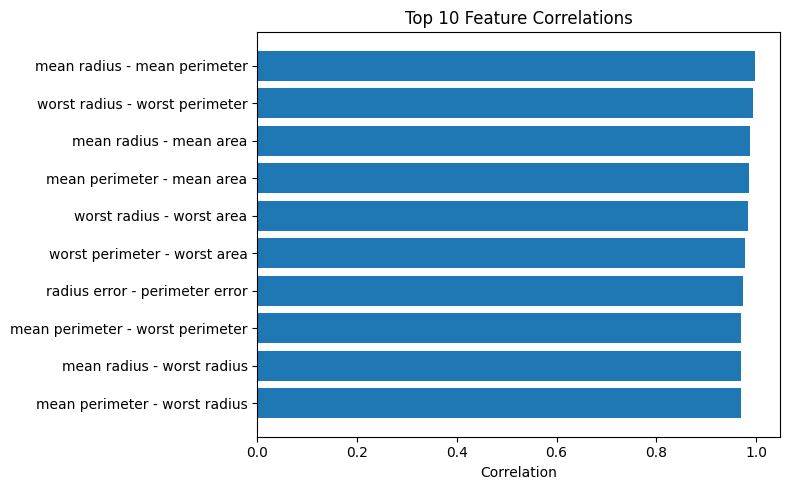

In [42]:
plt.figure(figsize=(8, 5))

labels = top_corr['Feature 1'] + ' - ' + top_corr['Feature 2']

plt.barh(labels, top_corr['Correlation'])
plt.xlabel('Correlation')
plt.title('Top 10 Feature Correlations')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Train-Test Split

In [43]:
X = df[data.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (455, 30)
Test shape: (114, 30)


# 6. Baseline Decision Tree

In [44]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Training Accuracy:", dt_model.score(X_train, y_train))
print("Testing Accuracy:", dt_model.score(X_test, y_test))


Training Accuracy: 1.0
Testing Accuracy: 0.9122807017543859


In [45]:
accuracy = accuracy_score(y_test, dt_pred)
precision = precision_score(y_test, dt_pred)
recall = recall_score(y_test, dt_pred)
f1 = f1_score(y_test, dt_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.9122807017543859
Precision: 0.9558823529411765
Recall: 0.9027777777777778
F1 Score: 0.9285714285714286


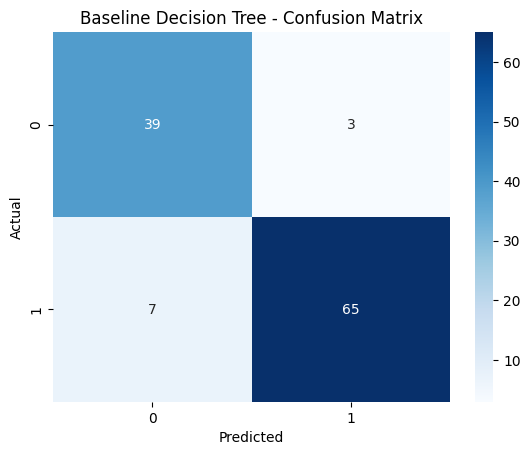

In [46]:
cm = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [47]:
print(classification_report(y_test, dt_pred))


              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



# 7. Decision Tree Hyperparameter Tuning

In [48]:
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy'
)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV Accuracy:", grid_dt.best_score_)


Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV Accuracy: 0.9384615384615385


In [49]:
# Summary table for a few criterion / max_depth combinations
results_dt = []

for criterion in ['gini', 'entropy']:
    for depth in [None, 3, 5, 7, 10]:
        model = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        scores = cross_validate(model, X_train, y_train, cv=5, scoring=['accuracy', 'f1'])
        results_dt.append({
            'Criterion': criterion,
            'Max Depth': depth,
            'Avg CV Accuracy (%)': scores['test_accuracy'].mean() * 100,
            'Avg CV F1 Score': scores['test_f1'].mean()
        })

dt_results_df = pd.DataFrame(results_dt)
dt_results_df


,Criterion,Max Depth,Avg CV Accuracy (%),Avg CV F1 Score
0,gini,NaN,90.989011,0.928176
1,gini,3.0,92.527473,0.941606
2,gini,5.0,93.186813,0.946139
3,gini,7.0,92.087912,0.937055
4,gini,10.0,90.989011,0.928176
5,entropy,NaN,93.186813,0.945049
6,entropy,3.0,92.967033,0.944088
7,entropy,5.0,92.527473,0.939662
8,entropy,7.0,93.186813,0.945049
9,entropy,10.0,93.186813,0.945049


# 8. Best Decision Tree Evaluation

In [50]:
best_dt = grid_dt.best_estimator_
best_dt.fit(X_train, y_train)

dt_best_pred = best_dt.predict(X_test)
dt_best_proba = best_dt.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, dt_best_pred))
print("Precision:", precision_score(y_test, dt_best_pred))
print("Recall:", recall_score(y_test, dt_best_pred))
print("F1 Score:", f1_score(y_test, dt_best_pred))


Accuracy: 0.9210526315789473
Precision: 0.9565217391304348
Recall: 0.9166666666666666
F1 Score: 0.9361702127659575


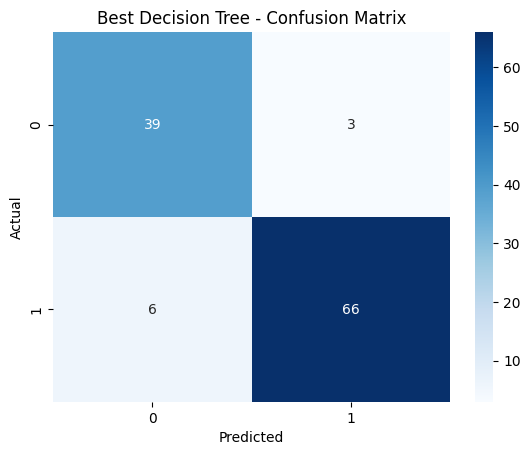

In [51]:
cm = confusion_matrix(y_test, dt_best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Best Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [52]:
print(classification_report(y_test, dt_best_pred))


              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



# 9. Baseline Random Forest

In [53]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))


Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


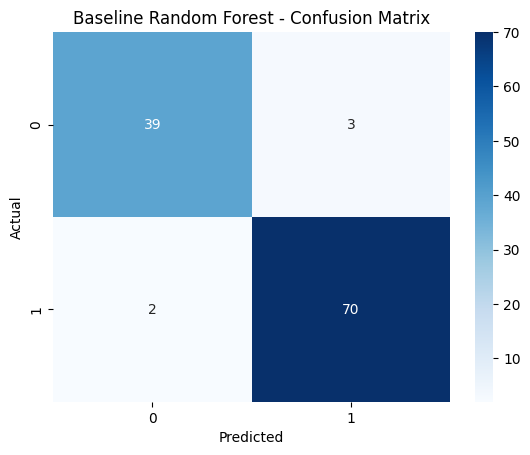

In [54]:
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Baseline Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [55]:
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# 10. Random Forest Hyperparameter Tuning

In [56]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)


Best Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
Best CV Accuracy: 0.9692307692307693


In [57]:
# Summary table for a few n_estimators / max_depth / max_features combinations
results_rf = []

for n_est in [50, 100, 200]:
    for depth in [None, 5, 10]:
        for max_feat in ['sqrt', 'log2']:
            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                max_features=max_feat,
                random_state=42
            )
            scores = cross_validate(model, X_train, y_train, cv=5, scoring=['accuracy', 'f1'])
            results_rf.append({
                'n_estimators': n_est,
                'Max Depth': depth,
                'Max Features': max_feat,
                'Avg CV Accuracy (%)': scores['test_accuracy'].mean() * 100,
                'Avg CV F1 Score': scores['test_f1'].mean()
            })

rf_results_df = pd.DataFrame(results_rf)
rf_results_df


,n_estimators,Max Depth,Max Features,Avg CV Accuracy (%),Avg CV F1 Score
0,50,NaN,sqrt,95.164835,0.961730
1,50,NaN,log2,95.384615,0.963134
2,50,5.0,sqrt,95.164835,0.961855
3,50,5.0,log2,95.164835,0.961610
4,50,10.0,sqrt,95.164835,0.961730
5,50,10.0,log2,95.384615,0.963134
6,100,NaN,sqrt,95.384615,0.963408
7,100,NaN,log2,95.604396,0.964844
8,100,5.0,sqrt,94.945055,0.960054
9,100,5.0,log2,95.164835,0.961523


# 11. Best Random Forest Evaluation

In [58]:
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train, y_train)

rf_best_pred = best_rf.predict(X_test)
rf_best_proba = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_best_pred))
print("Precision:", precision_score(y_test, rf_best_pred))
print("Recall:", recall_score(y_test, rf_best_pred))
print("F1 Score:", f1_score(y_test, rf_best_pred))


Accuracy: 0.956140350877193
Precision: 0.958904109589041
Recall: 0.9722222222222222
F1 Score: 0.9655172413793104


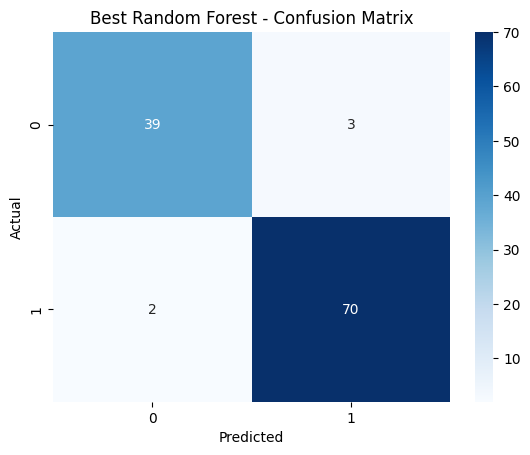

In [59]:
cm = confusion_matrix(y_test, rf_best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Best Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [60]:
print(classification_report(y_test, rf_best_pred))


              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# 12. ROC Curve and AUC

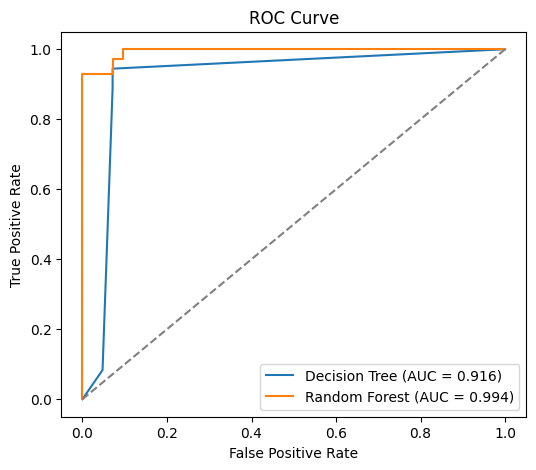

Decision Tree AUC: 0.9163359788359788
Random Forest AUC: 0.994378306878307


In [61]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_best_proba)
auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_best_proba)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("Decision Tree AUC:", auc_dt)
print("Random Forest AUC:", auc_rf)


# 13. Decision Tree vs Random Forest Comparison

In [62]:
comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, dt_best_pred), accuracy_score(y_test, rf_best_pred)],
    'Precision': [precision_score(y_test, dt_best_pred), precision_score(y_test, rf_best_pred)],
    'Recall': [recall_score(y_test, dt_best_pred), recall_score(y_test, rf_best_pred)],
    'F1 Score': [f1_score(y_test, dt_best_pred), f1_score(y_test, rf_best_pred)]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.921053,0.956522,0.916667,0.936170
1,Random Forest,0.956140,0.958904,0.972222,0.965517


# 14. 5-Fold Cross-Validation Performance Comparison

In [63]:
dt_cv_scores = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='accuracy')
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy')

cv_comparison_df = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Fold 1': [dt_cv_scores[0], rf_cv_scores[0]],
    'Fold 2': [dt_cv_scores[1], rf_cv_scores[1]],
    'Fold 3': [dt_cv_scores[2], rf_cv_scores[2]],
    'Fold 4': [dt_cv_scores[3], rf_cv_scores[3]],
    'Fold 5': [dt_cv_scores[4], rf_cv_scores[4]],
    'Average': [dt_cv_scores.mean(), rf_cv_scores.mean()]
})

cv_comparison_df


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Decision Tree,0.945055,0.945055,0.901099,0.945055,0.956044,0.938462
1,Random Forest,0.978022,1.000000,0.934066,0.956044,0.978022,0.969231
